In [19]:
# !pip install scanpy anndata matplotlib numpy pandas
import re
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 2
sc.set_figure_params(dpi=120)

In [ ]:
# Path to RNA data: cells as rows, columns = genes + "h" (timepoint)
MATRIX_PATH = "data/rna/rna.csv"
SEP = ","

# Load CSV: rows = cells, columns = genes + "h"
df = pd.read_csv(MATRIX_PATH, sep=SEP)
gene_cols = [c for c in df.columns if c != "h"]
# Assign cell IDs for pseudotime ordering (used when saving reordered data)
df.index = [f"Cell_{i}" for i in range(len(df))]

print(df.shape, " (cells x [genes + h])")
print(f"Genes: {len(gene_cols)}, Time column: 'h'")
df[gene_cols[:5] + ["h"]].head(3)

: 

In [ ]:
# Create AnnData: cells as rows, genes as columns (already in this format)
adata = sc.AnnData(df[gene_cols].copy())
adata.obs_names = df.index.tolist()
adata.var_names_make_unique()

# Timepoint from the "h" column (no parsing from cell names)
adata.obs["timepoint_h"] = df["h"].values
adata.obs["well"] = adata.obs_names  # optional; no well IDs in this dataset

print(f"AnnData shape: {adata.shape} (cells x genes)")
print(f"\nTimepoint distribution:")
print(adata.obs["timepoint_h"].value_counts().sort_index())


In [33]:
import numpy as np

rng = np.random.default_rng(42)  # set seed for reproducibility

# indices of earliest-timepoint cells (0 h)
tp = adata.obs["timepoint_h"].values
earliest_tp = np.nanmin(tp)
early_idx = np.where(tp == earliest_tp)[0]
n_roots = int(np.ceil(len(early_idx) / 2))

roots = rng.choice(early_idx, size=n_roots, replace=False)
print(f"earliest timepoint: {earliest_tp} h | candidates={len(early_idx)} | sampled roots={len(roots)}")

earliest timepoint: 0.0 h | candidates=90 | sampled roots=45


In [35]:
# --- Graph build for log-normalized scRNA-seq ---

import numpy as np
import scanpy as sc
import re
from scipy.sparse.csgraph import connected_components

# 0) basic gene filter
sc.pp.filter_genes(adata, min_cells=3)

# 1) mark MT / ribosomal genes so they don’t become HVGs
mt_mask = (
    adata.var_names.str.lower().str.startswith("mt-") |
    adata.var_names.str.upper().str.startswith(("MT-", "MT_"))
)
ribo_mask = adata.var_names.str.match(r"(?i)^RP[LS]\d")

# 2) HVGs (non-counts flavor), then drop MT/ribo
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=3000, subset=False)
keep_mask = adata.var["highly_variable"] & ~mt_mask & ~ribo_mask
adata = adata[:, keep_mask].copy()

# 3) scale & PCA (choose PCs to reach ~90% variance; clamp to [20, 60])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=100, svd_solver="arpack")
vr = adata.uns["pca"]["variance_ratio"]
NPCS = int(np.clip(np.searchsorted(np.cumsum(vr), 0.90) + 1, 20, 60))
print(f"[graph] Using n_pcs={NPCS}")

# 4) kNN graph (cosine works well on log1p/TPM) → diffusion map
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=NPCS, metric="cosine")
sc.tl.diffmap(adata)

# quick sanity on the graph
ncomp, labels = connected_components(adata.obsp["connectivities"], directed=False)
adata.obs["graph_comp"] = labels
deg = np.asarray(adata.obsp["connectivities"].sum(axis=1)).ravel()
print(f"[graph] components={ncomp} | degree mean±sd={deg.mean():.1f}±{deg.std():.1f}")

extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=100
    finished (0:00:01)
[graph] Using n_pcs=60
computing neighbors
    using 'X_pca' with n_pcs = 60
    finished (0:00:00)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9893325  0.96623033 0.8957374  0.8208391  0.771222
     0.74026394 0.71334386 0.6900047  0.65677816 0.62889296 0.62421626
     0.60640746 0.58970445 0.5775959 ]
    finished (0:00:00)
[graph] components=1 | degree mean±sd=8.4±2.8


[consensus] earliest=0.0h | candidates=90 | roots=45
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9893325  0.96623033 0.8957374  0.8208391  0.771222
     0.74026394 0.71334386 0.6900047  0.65677816 0.62889296 0.62421626
     0.60640746 0.58970445 0.5775959 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0

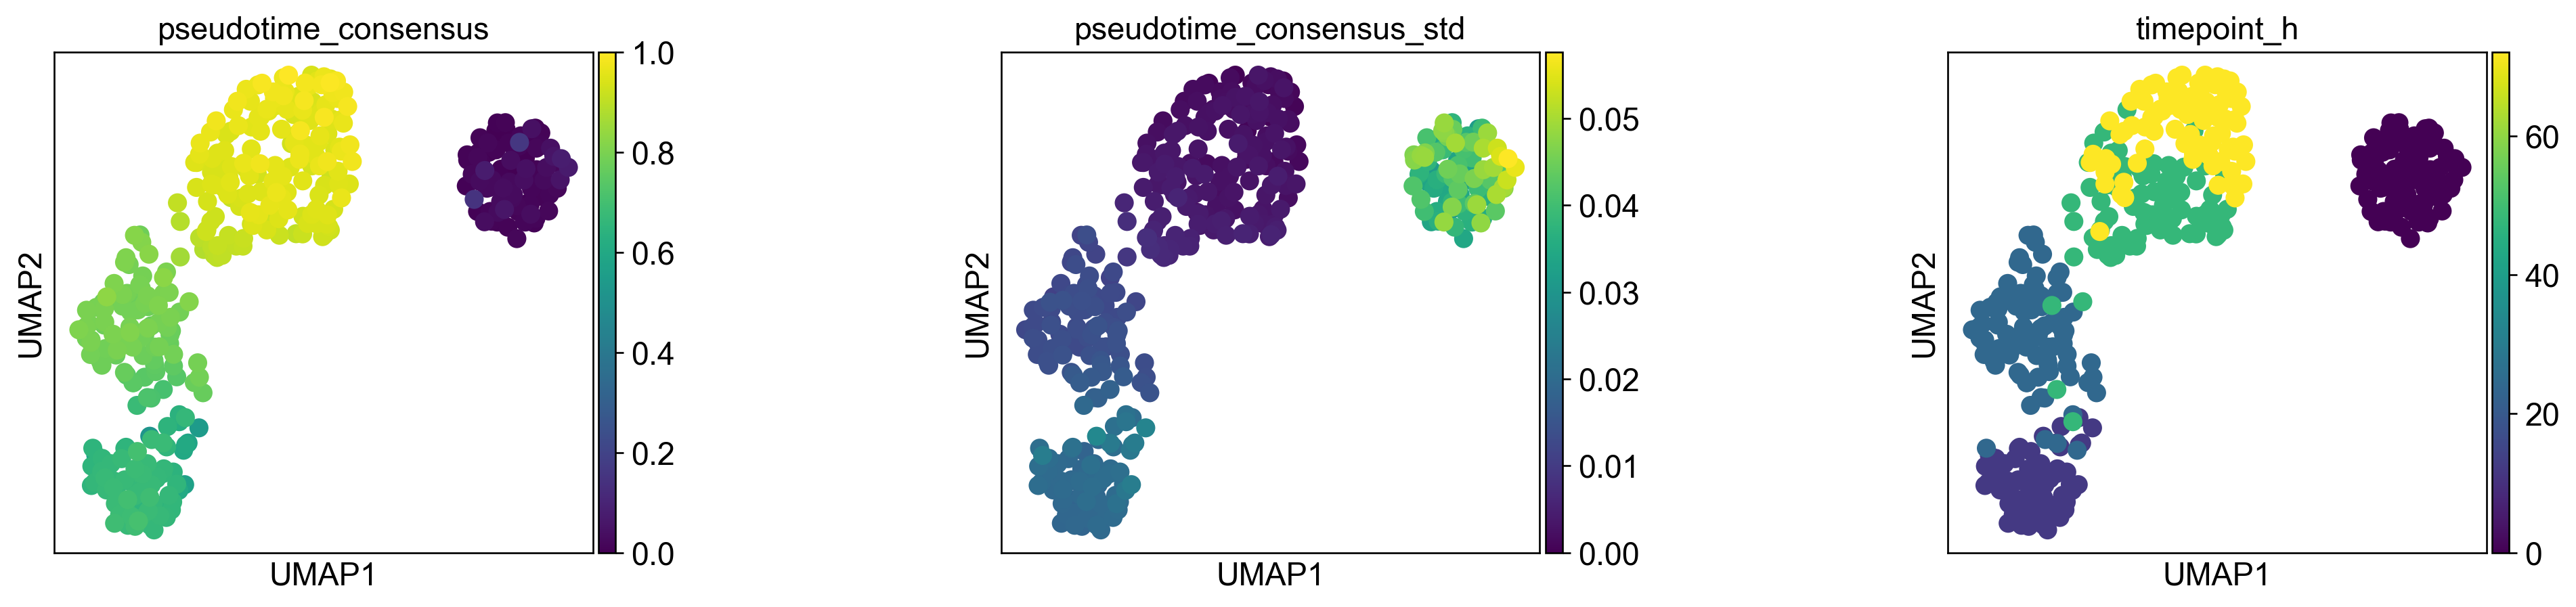

[consensus] saved cell_pseudotime_order_consensus.csv and adata_dpt_consensus.h5ad


In [36]:
# --- Consensus DPT over multiple roots ---

import numpy as np
import scanpy as sc

# pick ~half of the earliest timepoint cells as roots (reproducible)
rng = np.random.default_rng(42)
tp = adata.obs["timepoint_h"].values
earliest_tp = float(np.nanmin(tp))
early_idx = np.where(tp == earliest_tp)[0]
n_roots = max(1, int(np.ceil(len(early_idx) / 2)))
roots = rng.choice(early_idx, size=n_roots, replace=False)
print(f"[consensus] earliest={earliest_tp}h | candidates={len(early_idx)} | roots={len(roots)}")

# ensure diffusion map exists (cheap if already computed)
sc.tl.diffmap(adata)

# run DPT once per root and collect
PT = np.full((adata.n_obs, len(roots)), np.nan, dtype=float)
for j, r in enumerate(roots):
    adata.uns["iroot"] = int(r)
    sc.tl.dpt(adata, n_dcs=10)  # writes adata.obs['dpt_pseudotime']
    PT[:, j] = adata.obs["dpt_pseudotime"].values

# aggregate: median as consensus, std as stability; normalize 0–1
pt_med = np.nanmedian(PT, axis=1)
pt_std = np.nanstd(PT, axis=1)
pt_cons = (pt_med - np.nanmin(pt_med)) / (np.nanmax(pt_med) - np.nanmin(pt_med) + 1e-12)

adata.obs["pseudotime_consensus"] = pt_cons
adata.obs["pseudotime_consensus_std"] = pt_std
adata.obsm["pseudotime_roots_matrix"] = PT
print("[consensus] wrote adata.obs['pseudotime_consensus'] and ['pseudotime_consensus_std']")

# optional visualization & export
if "X_umap" not in adata.obsm:
    sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["pseudotime_consensus", "pseudotime_consensus_std", "timepoint_h"],
    cmap="viridis",
    wspace=0.6,
)

order = adata.obs.sort_values("pseudotime_consensus")[["pseudotime_consensus","timepoint_h","graph_comp","well"]].copy()
order["pt_rank"] = range(1, len(order)+1)
order.to_csv("cell_pseudotime_order_consensus.csv")
adata.write("adata_dpt_consensus.h5ad")
print("[consensus] saved cell_pseudotime_order_consensus.csv and adata_dpt_consensus.h5ad")

In [ ]:
# =============================================================================
# Reorder the original data by pseudotime and save in dataset_rna format
# Output: cells as rows, columns = genes + "h" (same as data/rna/rna.csv)
# =============================================================================
import pandas as pd

# Get cell order sorted by pseudotime (lowest to highest)
cell_order = adata.obs.sort_values("pseudotime_consensus").index.tolist()
print(f"Total cells to reorder: {len(cell_order)}")

# Expression matrix: genes as rows, cells as columns (for reordering)
original_df = df[gene_cols].T
original_df.columns = df.index
print(f"Original shape: {original_df.shape} (genes x cells)")

# Reorder columns (cells) by pseudotime
reordered_df = original_df[cell_order]
print(f"Reordered shape: {reordered_df.shape} (genes x cells)")

# Save in dataset_rna format: cells x (genes + h)
# Rows = cells (reordered by pseudotime), columns = gene_cols + "h"
reordered_cells = reordered_df.T
reordered_cells["h"] = adata.obs.loc[cell_order, "timepoint_h"].values
OUTPUT_PATH = "data/rna/rna_reordered_dpt.csv"
reordered_cells.to_csv(OUTPUT_PATH, index=False)
print(f"\n✓ Saved to: {OUTPUT_PATH} (cells x [genes + h])")

# =============================================================================
# VERIFICATION
# =============================================================================
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

print(f"\nFirst 10 cells (by pseudotime order):")
for i, cell_id in enumerate(cell_order[:10]):
    pt = adata.obs.loc[cell_id, "pseudotime_consensus"]
    orig_tp = adata.obs.loc[cell_id, "timepoint_h"]
    print(f"  {i+1}. {cell_id} | pseudotime={pt:.4f} | timepoint_h={orig_tp}")

print(f"\nLast 5 cells (by pseudotime order):")
for i, cell_id in enumerate(cell_order[-5:]):
    pt = adata.obs.loc[cell_id, "pseudotime_consensus"]
    orig_tp = adata.obs.loc[cell_id, "timepoint_h"]
    print(f"  {len(cell_order)-4+i}. {cell_id} | pseudotime={pt:.4f} | timepoint_h={orig_tp}")

print(f"\nGenes preserved: {gene_cols[:5]} ... total {len(gene_cols)}")

print("\nTimepoint distribution in reordered data:")
tp_counts = pd.Series(adata.obs.loc[cell_order, "timepoint_h"]).value_counts().sort_index()
print(tp_counts)

print("\n✓ Format compatible with dataset_rna.py (cells x [genes + h])")

Counts per discrete time (aligned):
0.0      90
12.0     75
24.0     87
48.0     49
72.0    120
Name: count, dtype: int64


In [ ]:
# =============================================================================
# USAGE INSTRUCTIONS
# =============================================================================
print("="*70)
print("HOW TO USE THE REORDERED DATA WITH CSDI")
print("="*70)

print("""
The reordered CSV has the same format as data/rna/rna.csv:
  - Rows: Cells (ordered by pseudotime)
  - Columns: Genes + "h" (timepoint)

TO USE:
  1. Run the reorder training script (uses dataset_rna with reordered file):
     python exe_rna_reorder.py --config base.yaml --testmissingratio 0.1 --nsample 100

  2. Clear cache if you change missing_ratio or seed:
     rm -f data/rna/rna_reordered_dpt_missing*_seed*.pk
     (cache is keyed by path, so reordered file uses its own cache)
""")

# Show pseudotime order summary
order_info = adata.obs.sort_values("pseudotime_consensus")[["pseudotime_consensus", "timepoint_h", "well"]]
print("\nFirst 15 cells (earliest pseudotime):")
print(order_info.head(15))

print("\nLast 15 cells (latest pseudotime):")
print(order_info.tail(15))
